
 Logistic Regression Baseline
              precision    recall  f1-score   support

         0.0       0.81      0.99      0.89       828
         1.0       0.72      0.09      0.16       206

    accuracy                           0.81      1034
   macro avg       0.77      0.54      0.52      1034
weighted avg       0.80      0.81      0.75      1034



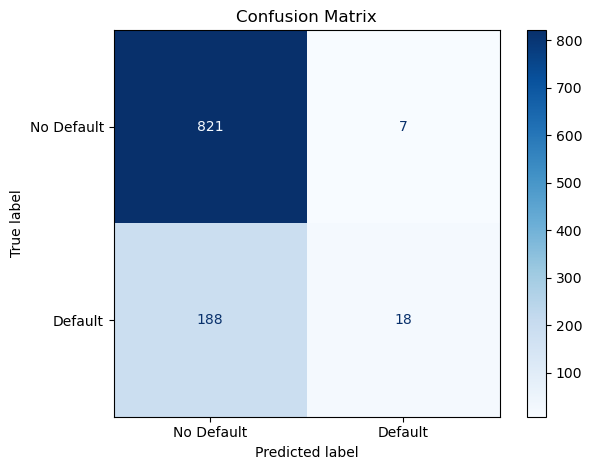

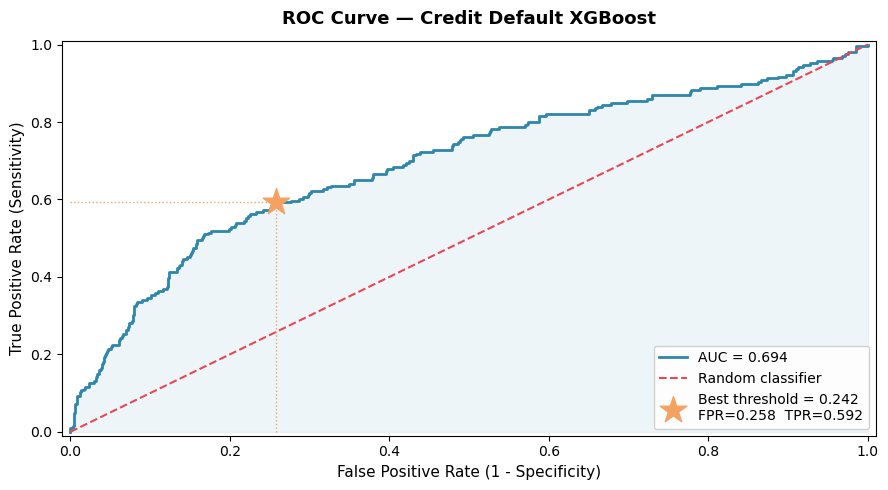

5-Fold Cross Validation
  Fold 1/5 — AUC: 0.9926
  Fold 2/5 — AUC: 0.9916
  Fold 3/5 — AUC: 0.9856
  Fold 4/5 — AUC: 0.9910
  Fold 5/5 — AUC: 0.9960

  CV Mean AUC: 0.9914 ± 0.0033


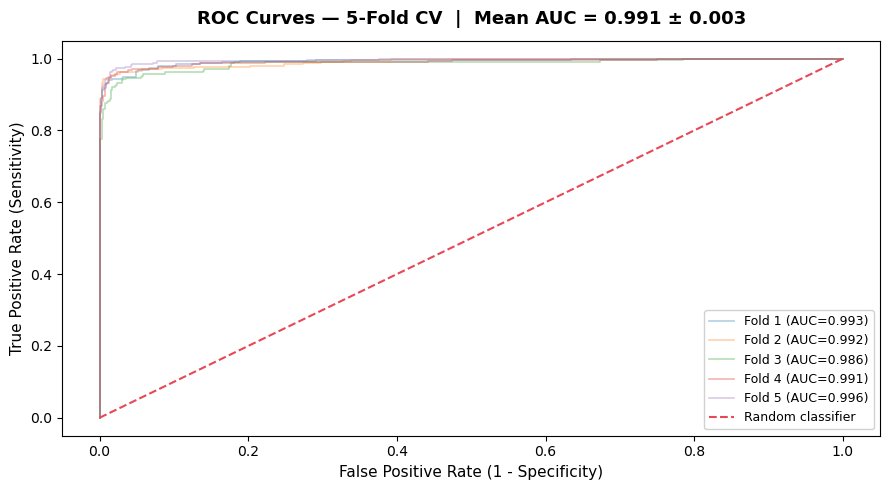


 validation Results


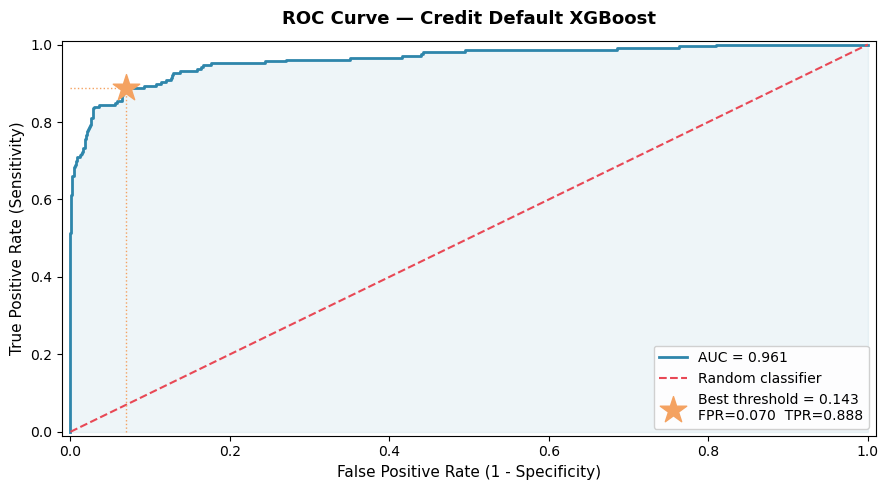

Total Portfolio EAD:            $76,593,144.82
Expected Loss:                  $964,766.50  (1.26%)
Average PD:                     16.68%
Weighted Average PD:            14.73%

New Portfolio (Amortized):      $39,116,167.18
Actual Loss (missed defaults):  $955,938.58  (2.44%)
Opportunity Cost:               $2,124,620.87  (5.43%)

             n_loans          EAD             EL    Avg_PD    EL_pct
risk_bucket                                                         
Low              259  20612223.00   13220.667168  0.008425  0.000641
Medium           258  20346721.00   43356.602811  0.021629  0.002131
High             258  19418488.00  117269.015587  0.062582  0.006039
Very High        259  16215712.82  790920.213819  0.573524  0.048775
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95       828
         1.0       0.76      0.89      0.82       206

    accuracy                           0.92      1034
   macro avg       0.87      0.91

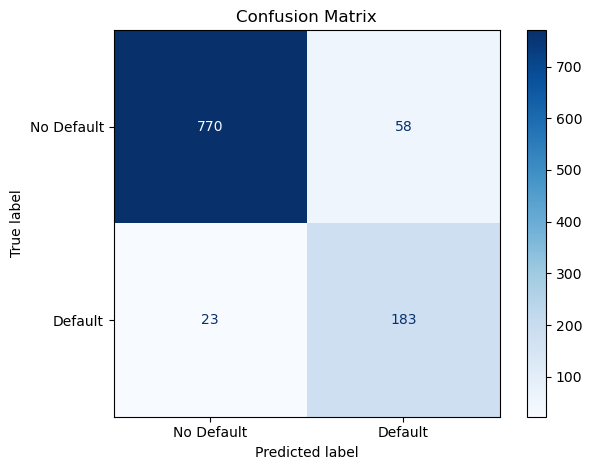

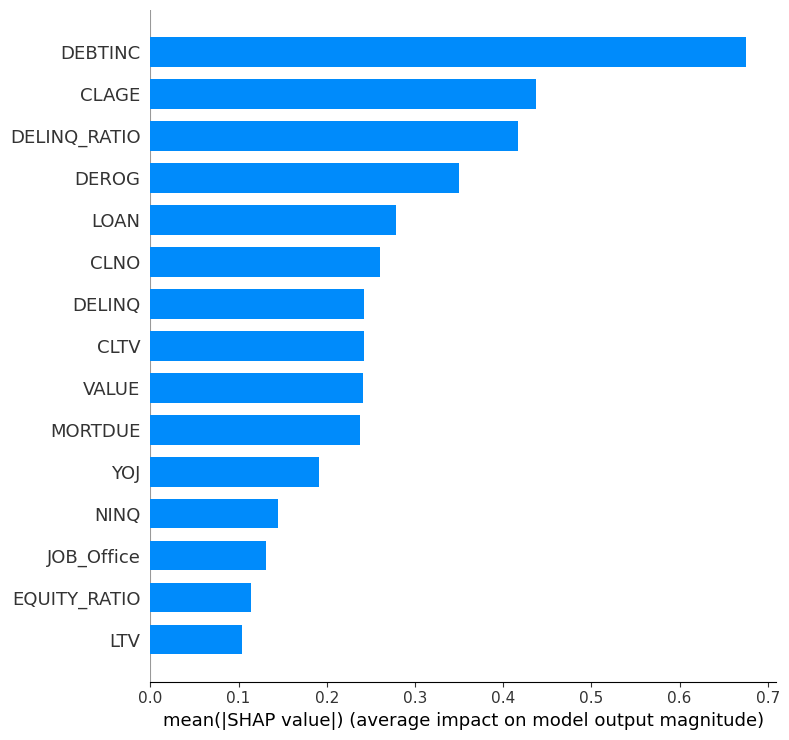

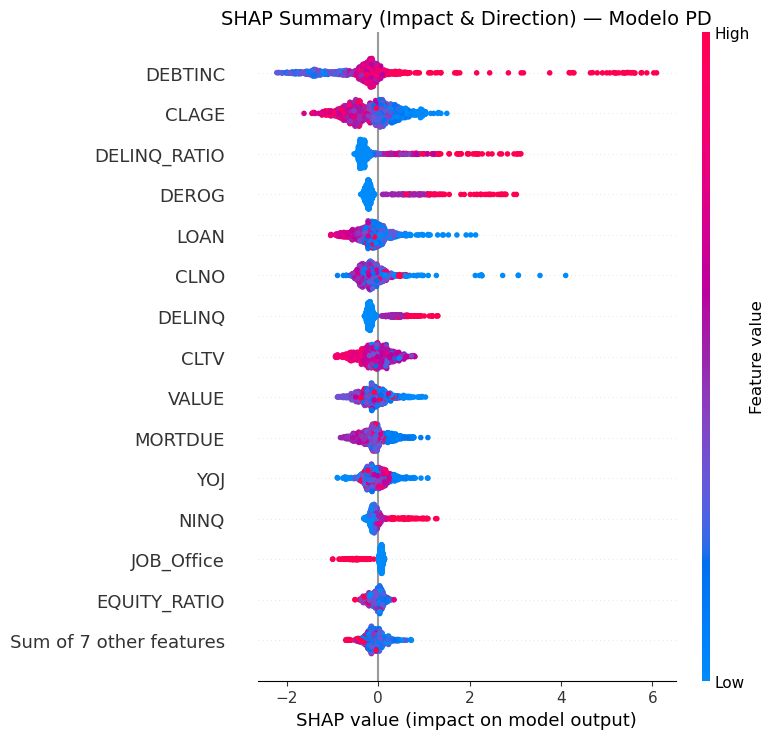

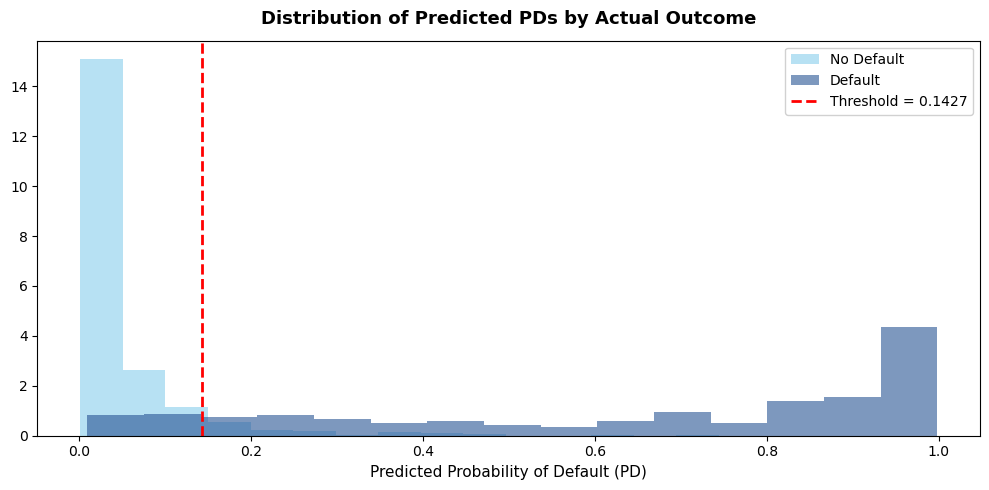

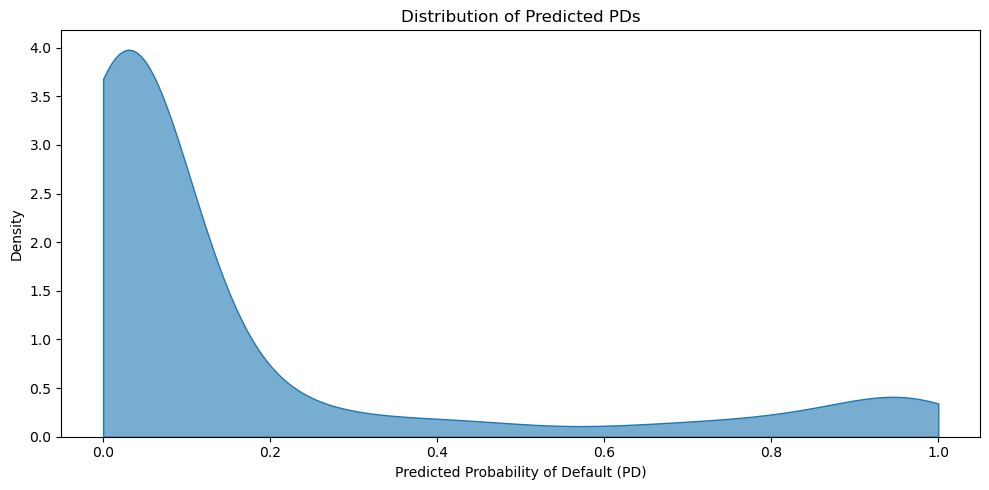


 Test Results


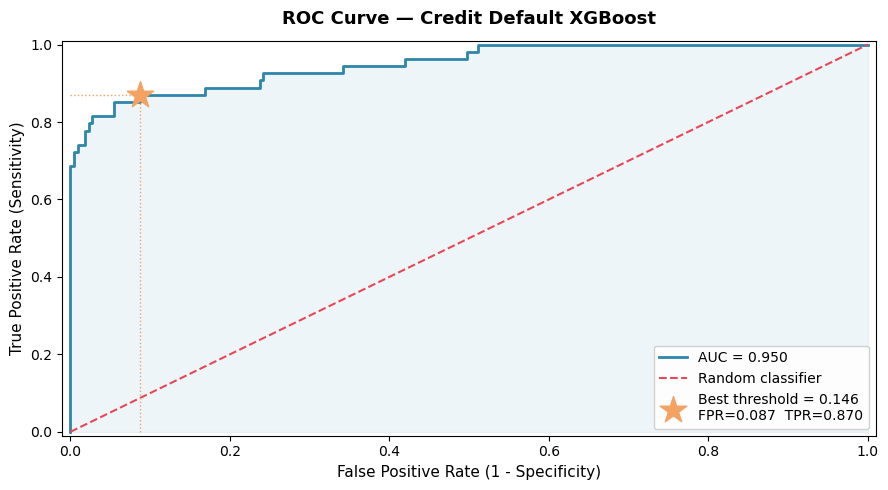

              precision    recall  f1-score   support

         0.0       0.97      0.91      0.94       219
         1.0       0.70      0.87      0.78        54

    accuracy                           0.90       273
   macro avg       0.83      0.89      0.86       273
weighted avg       0.91      0.90      0.90       273



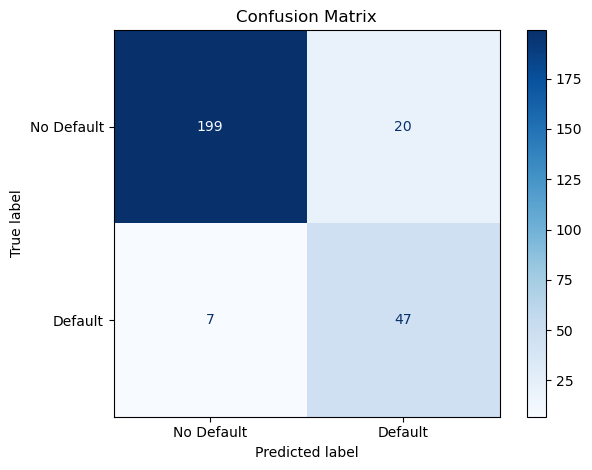

Total Portfolio EAD:            $19,518,852.86
Expected Loss:                  $236,423.26  (1.21%)
Average PD:                     16.85%
Weighted Average PD:            14.53%

New Portfolio (Amortized):      $10,668,673.98
Actual Loss (missed defaults):  $360,973.06  (3.38%)
Opportunity Cost:               $830,238.04  (7.78%)

             n_loans         EAD             EL    Avg_PD    EL_pct
risk_bucket                                                        
Low               69  5079702.00    1662.771134  0.008481  0.000327
Medium            68  5431858.86   10892.332747  0.023549  0.002005
High              68  4997544.00   30577.309750  0.071677  0.006118
Very High         68  4009748.00  193290.847460  0.572761  0.048205


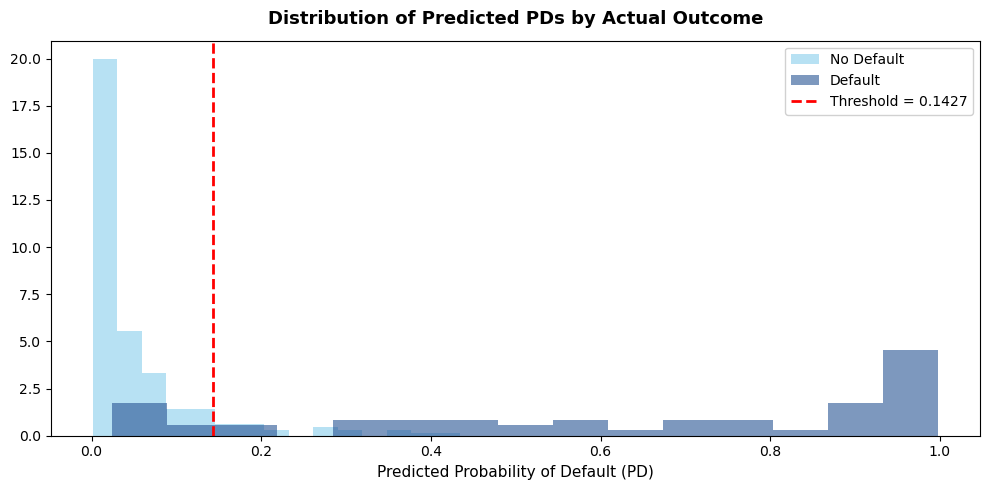

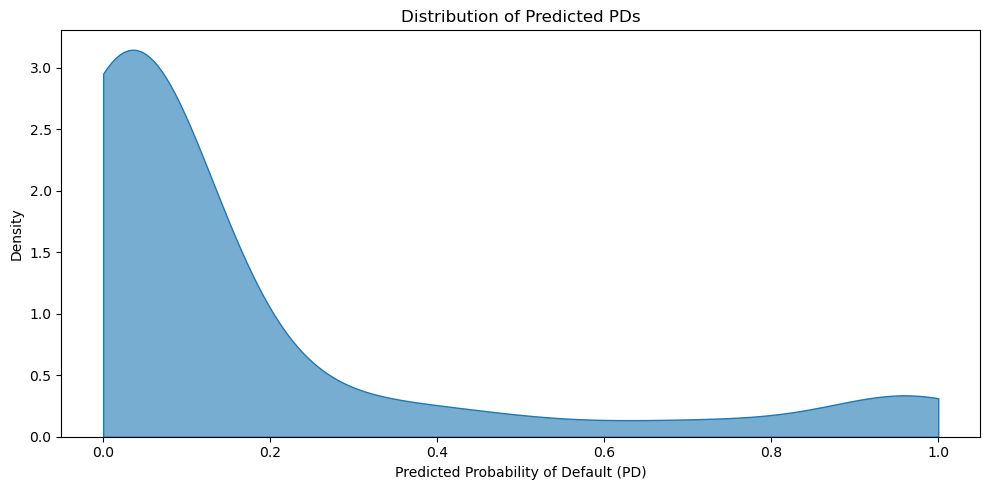

In [50]:
import shap
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from typing import Any
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
# LAYER 0 — BASE EXTRACTOR
# Single responsibility: pull one column from a DataFrame.
# All feature functions compose from this.
# ══════════════════════════════════════════════════════════════════


def _col(df: pd.DataFrame, col: str) -> pd.Series:
    """Return a single column from a DataFrame as a Series."""
    return df[col]


# ══════════════════════════════════════════════════════════════════
# LAYER 1 — DATA INGESTION
# ══════════════════════════════════════════════════════════════════

def load_data(filename: str) -> pd.DataFrame:
    """
    Load a dataset from a CSV file into a DataFrame.

    Args:
        filename     (str): CSV filename inside the downloaded folder.

    Returns:
        pd.DataFrame: Raw dataset.
    """
    return pd.read_csv(filename)


# ══════════════════════════════════════════════════════════════════
# LAYER 2 — MORTGAGE FEATURE FUNCTIONS AND METRICS CALCULATIONS
# Each function computes one ratio or metric and composes from _col().
# ══════════════════════════════════════════════════════════════════

def total_debt(df: pd.DataFrame) -> pd.Series:
    """Total debt: new loan request plus existing mortgage balance."""
    return _col(df, 'LOAN') + _col(df, 'MORTDUE')


def ltv(df: pd.DataFrame) -> pd.Series:
    """
    Loan-to-Value ratio: new loan vs. appraised property value.
    Primary collateral risk metric for mortgage underwriting.
    """
    return _col(df, 'LOAN') / _col(df, 'VALUE')


def cltv(df: pd.DataFrame) -> pd.Series:
    """
    Combined Loan-to-Value: total debt (new + existing) vs. property value.
    Captures full leverage exposure on the collateral.
    """
    return total_debt(df) / _col(df, 'VALUE')


def home_equity(df: pd.DataFrame) -> pd.Series:
    """Owner equity in the property: appraised value minus existing mortgage."""
    return _col(df, 'VALUE') - _col(df, 'MORTDUE')


def equity_ratio(df: pd.DataFrame) -> pd.Series:
    """
    Equity ratio: owner equity as a fraction of property value.
    Complement of LTV for the existing mortgage.
    """
    return home_equity(df) / _col(df, 'VALUE')


def delinq_ratio(df: pd.DataFrame) -> pd.Series:
    """
    Delinquency ratio: delinquent credit lines over total credit lines.
    +1 in denominator avoids division by zero for clients with no credit lines.
    """
    return _col(df, 'DELINQ') / (_col(df, 'CLNO') + 1)


def underwater(df: pd.DataFrame) -> pd.Series:
    """
    Underwater flag: 1 if total debt exceeds property value, 0 otherwise.
    Indicates negative equity — the strongest single predictor of LGD.
    """
    return (total_debt(df) > _col(df, 'VALUE')).astype(int)


def portfolio_ead(data_test: pd.DataFrame) -> float:
    """Total outstanding exposure across the portfolio."""
    return _col(data_test, 'MORTDUE').sum()


def new_portfolio_value(data_test: pd.DataFrame) -> float:
    """Total amortized value of loans approved by the model."""
    return data_test.loc[data_test['model_prediction'] == 0, 'amortized_loans'].sum()


def expected_loss(data_test: pd.DataFrame) -> float:
    """Portfolio-level Expected Loss: sum of PD × LGD × EAD."""
    return _col(data_test, 'EL_amount').sum()


def actual_loss(data_test: pd.DataFrame) -> float:
    """
    Loss from missed defaults: approved loans that actually defaulted.
    Model predicted 0 (approve) but true label is 1 (default).
    """
    return data_test.loc[
        (data_test['model_prediction'] == 0) & (data_test['BAD'] == 1),
        'amortized_loans'
    ].sum()


def opportunity_cost(data_test: pd.DataFrame) -> float:
    """
    Foregone income from incorrectly rejected good clients.
    Model predicted 1 (reject) but true label is 0 (no default).
    """
    return data_test.loc[
        (data_test['model_prediction'] == 1) & (data_test['BAD'] == 0),
        'amortized_loans'
    ].sum()


def mean_pd(data_test: pd.DataFrame) -> float:
    """Simple average PD across all loans in the portfolio."""
    return _col(data_test, 'default_proba').mean()


def weighted_pd(data_test: pd.DataFrame) -> float:
    """
    EAD-weighted average PD.
    Larger loans contribute proportionally more to the portfolio PD.
    """
    weights = _col(data_test, 'MORTDUE') / _col(data_test, 'MORTDUE').sum()
    return (weights * _col(data_test, 'default_proba')).sum()


# ══════════════════════════════════════════════════════════════════
# LAYER 3 — FEATURE ENGINEERING PIPELINE
# Composes all feature functions above into a single transformation.
# ══════════════════════════════════════════════════════════════════

def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive mortgage-specific risk features from raw columns.

    Composes: total_debt(), ltv(), cltv(), home_equity(),
              equity_ratio(), delinq_ratio(), underwater().

    Note: HOME_EQUITY and TOTAL_DEBT are intermediate values used
    to compute other ratios. They are dropped before model training
    to prevent data leakage (they directly encode the target signal).

    Args:
        df (pd.DataFrame): Preprocessed DataFrame with raw columns.

    Returns:
        pd.DataFrame: DataFrame with derived features appended.
    """
    df = df.copy()
    df['TOTAL_DEBT'] = total_debt(df)
    df['LTV'] = ltv(df)
    df['CLTV'] = cltv(df)
    df['HOME_EQUITY'] = home_equity(df)
    df['EQUITY_RATIO'] = equity_ratio(df)
    df['DELINQ_RATIO'] = delinq_ratio(df)
    df['UNDERWATER'] = underwater(df)
    return df


# ══════════════════════════════════════════════════════════════════
# LAYER 4 — MODEL INPUTS
# ══════════════════════════════════════════════════════════════════

def prepare_model_inputs(
    df: pd.DataFrame,
    target: str,
    drop_cols: list[str],
    test_size: float = 0.2,
    random_state: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Split data into stratified train/test sets.

    Args:
        df           (pd.DataFrame): Full preprocessed DataFrame.
        target       (str)         : Name of the binary target column.
        drop_cols    (list[str])   : Columns to exclude from features
                                     (intermediates or leakage sources).
        test_size    (float)       : Fraction reserved for testing.
        random_state (int)         : Reproducibility seed.

    Returns:
        tuple: (X_train, X_test, y_train, y_test)
    """
    X = df.drop(columns=[target] + drop_cols)
    y = df[target]
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state, stratify=y)


# ══════════════════════════════════════════════════════════════════
# LAYER 5 — MODEL TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════════

def train_logistic_regression(X_train: pd.DataFrame, y_train: pd.Series) -> LogisticRegression:
    """
    Train a logistic regression model as a baseline.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series)   : Training labels.

    Returns:
        LogisticRegression: Fitted logistic regression model.
    """
    model = LogisticRegression()
    model.fit(X_train, y_train)
    return model


def train_xgboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    random_state: int
) -> XGBClassifier:
    """
    Train an XGBoost classifier.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training labels.
        X_val (pd.DataFrame): Validation features.
        y_val (pd.Series): Validation labels.
        random_state (int, optional): Random state for reproducibility.

    Returns:
        XGBClassifier: Fitted XGBoost classifier.
    """
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.01,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.7,
        tree_method='hist',
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=0
    )
    return model


def bootstrap_training_data(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_samples: int = None,
    random_state: int = 10
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Generate a larger training set via bootstrap resampling.

    Args:
        X_train      : Original training features.
        y_train      : Original training labels.
        n_samples    : How many rows to sample. Defaults to 2x original size.
        random_state : Reproducibility seed.

    Returns:
        tuple: (X_boot, y_boot) — bootstrapped features and labels.
    """
    rng = np.random.default_rng(random_state)
    n = len(X_train)

    if n_samples is None:
        n_samples = n * 2   # default: double your data

    idx = rng.integers(0, n, size=n_samples)   # sample WITH replacement
    X_boot = X_train.iloc[idx].reset_index(drop=True)
    y_boot = y_train.iloc[idx].reset_index(drop=True)

    return X_boot, y_boot


def model_predictions(model: Any, X_test: pd.DataFrame) -> np.ndarray:
    """
    Get predicted probabilities of default from the model.

    Args:
        model  (LogisticRegression): Fitted logistic regression model.
        X_test (pd.DataFrame)      : Test features.

    Returns:
        np.ndarray: Predicted probabilities of default for the test set.
    """
    return model.predict(X_test), model.predict_proba(X_test)[:, 1]


def curva_roc(probabilidades: np.ndarray, y_test: np.ndarray) -> float:
    """
    Plot the ROC curve and return the optimal classification threshold.

    The optimal threshold minimises the Euclidean distance to the
    perfect-classifier point (FPR=0, TPR=1) on the ROC curve.

    Args:
        probabilidades (np.ndarray): Predicted probabilities of default.
        y_test         (np.ndarray): True binary labels.

    Returns:
        float: Optimal threshold value.
    """
    fpr, tpr, thresholds = roc_curve(y_score=probabilidades, y_true=y_test)

    distances = np.sqrt(fpr**2 + (1 - tpr)**2)
    best_idx = np.argmin(distances)
    best_thr = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]
    auc_score = roc_auc_score(y_test, probabilidades)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(fpr, tpr, alpha=0.08, color='#2E86AB')
    ax.plot(fpr, tpr, color='#2E86AB', lw=2, label=f'AUC = {auc_score:.3f}')
    ax.plot([0, 1], [0, 1], color='#E84855', lw=1.5, linestyle='--',
            label='Random classifier')
    ax.plot([best_fpr, best_fpr], [0, best_tpr],
            color='#F4A261', lw=1, linestyle=':')
    ax.plot([0, best_fpr], [best_tpr, best_tpr],
            color='#F4A261', lw=1, linestyle=':')
    ax.scatter(best_fpr, best_tpr, marker='*', s=400, color='#F4A261',
               zorder=5, label=(f'Best threshold = {best_thr:.3f}\n'
                                f'FPR={best_fpr:.3f}  TPR={best_tpr:.3f}'))
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
    ax.set_title('ROC Curve — Credit Default XGBoost',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10, framealpha=0.9, loc='lower right')
    plt.tight_layout()
    plt.show()

    return best_thr


def k_fold_cross_validation(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_splits: int,
    random_state: int
) -> dict:
    """
    Stratified K-Fold cross validation for the XGBoost PD model.

    Stratified ensures each fold preserves the original class ratio
    (important for imbalanced default datasets).

    Each fold trains on (k-1) folds and validates on the remaining one.
    Final metrics are averaged across all folds.

    Args:
        X_train      : Full training features (pre-split from test set).
        y_train      : Full training labels.
        n_splits     : Number of folds (default 5).
        random_state : Reproducibility seed.

    Returns:
        dict: {
            'fold_aucs'  : list of AUC per fold,
            'mean_auc'   : mean AUC across folds,
            'std_auc'    : standard deviation of AUC across folds,
            'fold_probas': list of (y_val_true, y_val_proba) per fold
        }
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                          random_state=random_state)
    fold_aucs = []
    fold_probas = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        model = train_xgboost(X_fold_train, y_fold_train,
                              X_fold_val, y_fold_val, random_state=random_state)

        _, y_val_proba = model_predictions(model, X_fold_val)
        auc = roc_auc_score(y_fold_val, y_val_proba)
        fold_aucs.append(auc)
        fold_probas.append((y_fold_val, y_val_proba))

        print(f"  Fold {fold}/{n_splits} — AUC: {auc:.4f}")

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    print(f"\n  CV Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

    return {
        'fold_aucs': fold_aucs,
        'mean_auc': mean_auc,
        'std_auc': std_auc,
        'fold_probas': fold_probas
    }, model


def plot_cv_roc_curves(fold_probas: list, n_splits: int = 5) -> None:
    """
    Plot individual fold ROC curves overlaid with the mean ROC curve.

    Args:
        fold_probas : List of (y_val_true, y_val_proba) tuples from cross_validate_xgboost().
        n_splits    : Number of folds (for labeling).
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    aucs = []

    for fold, (y_val, y_proba) in enumerate(fold_probas, start=1):
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        auc = roc_auc_score(y_val, y_proba)
        aucs.append(auc)
        ax.plot(fpr, tpr, alpha=0.35, lw=1.2,
                label=f'Fold {fold} (AUC={auc:.3f})')

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    ax.plot([0, 1], [0, 1], color='#E84855', lw=1.5,
            linestyle='--', label='Random classifier')
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
    ax.set_title(f'ROC Curves — {n_splits}-Fold CV  |  Mean AUC = {mean_auc:.3f} ± {std_auc:.3f}',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=9, framealpha=0.9, loc='lower right')
    plt.tight_layout()
    plt.show()


def probabilities_histogram(data_test: pd.DataFrame, threshold: float) -> None:
    """
    Plot the distribution of predicted PDs for defaults vs. non-defaults.

    Args:
        data_test (pd.DataFrame): Test set with 'default_proba' and 'BAD' columns.
        threshold (float): Classification threshold.
    """
    plt.figure(figsize=(10, 5))
    plt.hist(data_test[data_test['BAD'] == 0]['default_proba'], density=True, bins=15, alpha=0.6, color='skyblue', label='No Default')
    plt.hist(data_test[data_test['BAD'] == 1]['default_proba'], density=True, bins=15, alpha=0.6, color='#265393', label='Default')
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
    plt.xlabel('Predicted Probability of Default (PD)', fontsize=11)
    plt.title('Distribution of Predicted PDs by Actual Outcome', fontsize=13, fontweight='bold', pad=12)
    plt.legend(fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.show()


def pd_distribution(data_test: pd.DataFrame) -> None:
    """
    Plot the overall distribution (density) of predicted PDs.
    """
    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        data=data_test,
        x='default_proba',
        fill=True,
        alpha=0.6,
        clip=(0, 1)
    )

    plt.xlabel('Predicted Probability of Default (PD)')
    plt.title('Distribution of Predicted PDs')
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════
# LAYER 6 — EL COMPONENTS
# Three composable functions, one per Basel pillar: PD, LGD, EAD.
# ══════════════════════════════════════════════════════════════════

def net_recovery(property_value: np.ndarray, haircut: float) -> np.ndarray:
    """
    Net recoverable value of the collateral after foreclosure costs.

    The haircut captures legal fees, maintenance during the judicial
    process, and the fire-sale discount. A 30% haircut is consistent
    with Mexican mortgage foreclosure timelines (2-4 years via juicio
    hipotecario) per CNBV supervisory guidance.

    Args:
        property_value (np.ndarray): Appraised value of the property.
        haircut        (float)     : Foreclosure cost as % of value.

    Returns:
        np.ndarray: Net recovery amount per loan.
    """
    return property_value * (1 - haircut)


def actual_recovery(
    ead: np.ndarray,
    property_value: np.ndarray,
    haircut: float
) -> np.ndarray:
    """
    Amount actually recovered by the bank at default.

    The bank can recover at most the outstanding balance (EAD) —
    surplus collateral value does not generate income.

    Args:
        ead            (np.ndarray): Exposure at default (MORTDUE).
        property_value (np.ndarray): Appraised property value.
        haircut        (float)     : Foreclosure cost fraction.

    Returns:
        np.ndarray: Actual recovery per loan, capped at EAD.
    """
    return np.minimum(ead, net_recovery(property_value, haircut))


def lgd_hipotecario(
    ead: np.ndarray,
    property_value: np.ndarray,
    haircut: float = 0.30
) -> np.ndarray:
    """
    Loss Given Default for mortgage loans via collateral recovery model.

    Composes net_recovery() and actual_recovery().

    LGD = 1 - actual_recovery / EAD, clipped to [0, 1].

    A 30% haircut is calibrated so that portfolio-average LGD is
    consistent with the ~35% supervisory estimate for Mexican
    residential mortgages (Basel II IRB Foundation approach).

    Args:
        ead            (np.ndarray): Outstanding mortgage balance (MORTDUE).
        property_value (np.ndarray): Appraised property value (VALUE).
        haircut        (float)     : Foreclosure cost fraction (default 30%).

    Returns:
        np.ndarray: LGD values in [0, 1], one per loan.
    """
    recovery = actual_recovery(ead, property_value, haircut)
    return np.clip(1 - recovery / ead, 0, 1)


def amortization(
    principal: float | pd.Series,
    annual_rate: float,
    months: int
) -> float | pd.Series:
    """
    Total amount paid over the life of a fixed-payment mortgage.

    Uses the standard French amortization formula:
        C = P * r / (1 - (1+r)^-n)
    where r = monthly rate, n = number of payments.

    Used to estimate the new portfolio value after rejecting predicted defaults (opportunity cost)
    and to calculate actual loss on missed defaults (EAD of loans where model predicted 0 but true label is 1).

    Args:
        principal   (float | pd.Series): Original loan amount(s).
        annual_rate (float)            : Annual rate as percentage (e.g. 11.5040).
        months      (int)              : Total number of monthly payments.

    Returns:
        float | pd.Series: Total amount paid (principal + interest).
    """
    r = (annual_rate / 100) / 12
    payment = principal * (r / (1 - (1 + r) ** -months))
    return payment * months


# ══════════════════════════════════════════════════════════════════
# LAYER 7 — EL COMPUTATION
# ══════════════════════════════════════════════════════════════════

def compute_el(data_test: pd.DataFrame, best_thr: float, haircut: float) -> pd.DataFrame:
    """
    Compute Expected Loss components and model classification for each loan.

    EL = PD × LGD × EAD, where:
        PD  = default_proba (XGBoost output)
        LGD = lgd_hipotecario(MORTDUE, VALUE)   [composes net_recovery, actual_recovery]
        EAD = MORTDUE                            [outstanding balance, observed]

    Also assigns binary model_prediction using best_thr from curva_roc().

    Args:
        data_test (pd.DataFrame): Test set with default_proba already added.
        best_thr  (float)       : Optimal classification threshold.
        haircut   (float)       : Foreclosure cost fraction.
    Returns:
        pd.DataFrame: Input DataFrame with LGD, EL_pct, EL_amount,
                      and model_prediction columns added.
    """
    df = data_test.copy()
    df['LGD'] = lgd_hipotecario(
        ead=df['MORTDUE'].values,
        property_value=df['VALUE'].values,
        haircut=haircut
    )
    df['EL_pct'] = df['default_proba'] * df['LGD']
    df['EL_amount'] = df['default_proba'] * df['LGD'] * df['MORTDUE']
    df['model_prediction'] = (df['default_proba'] >= best_thr).astype(int)
    return df


# ══════════════════════════════════════════════════════════════════
# LAYER 8 — PORTFOLIO OUTPUTS
# ══════════════════════════════════════════════════════════════════

def compute_portfolio_metrics(data_test: pd.DataFrame, annual_rate: float, months: int) -> dict:
    """
    Compute all portfolio-level metrics into a single dictionary.

    Args:
        data_test (pd.DataFrame): Test set with computed EL components.
        annual_rate (float): Annual interest rate.
        months (int): Total number of monthly payments.

    Returns:
        dict: Dictionary containing all portfolio metrics.
    """
    # Add the amortized loan values to the DataFrame for loss calculations
    data_test['amortized_loans'] = amortization(
        principal=data_test['LOAN'], annual_rate=annual_rate, months=months)
    
    new_portfolio = new_portfolio_value(data_test)
    return {
        'ead'             : portfolio_ead(data_test),
        'new_portfolio'   : new_portfolio,
        'el'              : expected_loss(data_test),
        'actual_loss'     : actual_loss(data_test),
        'opportunity_cost': opportunity_cost(data_test),
        'mean_pd'         : mean_pd(data_test),
        'weighted_pd'     : weighted_pd(data_test),
    }


def portfolio_summary(data_test: pd.DataFrame, annual_rate: float, months: int) -> None:
    """
    Print portfolio-level metrics.

    Args:
        data_test (pd.DataFrame): Test set with computed EL components.
        annual_rate (float): Annual interest rate.
        months (int): Total number of monthly payments.
    """
    m  = compute_portfolio_metrics(data_test, annual_rate, months)
    new_portfolio = m['new_portfolio']

    print(f"Total Portfolio EAD:            ${m['ead']:,.2f}")
    print(f"Expected Loss:                  ${m['el']:,.2f}  ({m['el'] / m['ead']:.2%})")
    print(f"Average PD:                     {m['mean_pd']:.2%}")
    print(f"Weighted Average PD:            {m['weighted_pd']:.2%}\n")
    print(f"New Portfolio (Amortized):      ${new_portfolio:,.2f}")
    print(f"Actual Loss (missed defaults):  ${m['actual_loss']:,.2f}  ({m['actual_loss'] / new_portfolio:.2%})")
    print(f"Opportunity Cost:               ${m['opportunity_cost']:,.2f}  ({m['opportunity_cost'] / new_portfolio:.2%})\n")


def risk_bucket_table(data_test: pd.DataFrame) -> pd.DataFrame:
    """
    Segment the portfolio into four PD risk buckets and summarise EL metrics.

    Args:
        data_test (pd.DataFrame): Output of compute_el().

    Returns:
        pd.DataFrame: Summary table with n_creditos, EAD_total, EL_total,
                      PD_promedio, LGD_promedio, and EL_pct per bucket.
    """
    df = data_test.copy()

    # Crear 4 buckets por cuantiles
    df['risk_bucket'] = pd.qcut(
        df['default_proba'],
        q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )

    return df.groupby('risk_bucket', observed=True).agg(
        n_loans=('EL_amount',     'count'),
        EAD=('MORTDUE',       'sum'),
        EL=('EL_amount',     'sum'),
        Avg_PD=('default_proba', 'mean'),
        #LGD_promedio=('LGD',           'mean'),
    ).assign(
        EL_pct=lambda x: x['EL'] / x['EAD']
    )


def model_validation(y_pred: pd.Series, y_test: pd.Series) -> None:
    """
    Print classification report and plot confusion matrix.

    Args:
        y_test (pd.Series): True binary labels.
        y_pred (pd.Series): Model binary predictions.
    """
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Default', 'Default'],
        cmap='Blues'
    )
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def shap_analysis(model: XGBClassifier, X_test: pd.DataFrame, max_display: int = 15) -> None:
    """
    Generate SHAP feature importance plots for model interpretability.

    Produces two plots:
        1. Bar chart: mean absolute SHAP value per feature (global importance).
        2. Beeswarm: SHAP value distribution showing direction of impact.

    Args:
        model       (XGBClassifier): Fitted XGBoost model.
        X_test      (pd.DataFrame) : Test features.
        max_display (int)          : Number of top features to display.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)

    shap.summary_plot(shap_values, X_test, plot_type='bar',
                      max_display=max_display,
                      title='SHAP Feature Importance — Modelo PD Hipotecario')

    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values, max_display=max_display, show=False)
    plt.title('SHAP Summary (Impact & Direction) — Modelo PD', fontsize=14)
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════
# LAYER 9 — MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════


def main(
    filename: str = 'hmeq_cleaned.csv',
    filename_holdout: str = 'data_holdout.csv',
    target: str = 'BAD',
    haircut: float = 0.30,
    annual_rate: float = 11.5040,
    months: int = 240
):
    # NOTE: Three-way split strategy
    # - Train (76%): model fitting
    # - Validation (19%): threshold selection, hyperparameter evaluation,
    #                     overfitting detection during development
    # - Test (5%): final holdout, touched exactly once to report
    #              out-of-sample performance on unseen data

    # NOTE: LOAN represents the new credit requested by the applicant.
    # We assume the existing mortgage (MORTDUE) is already held by our bank.
    # Therefore:
    #   - EAD = MORTDUE (current outstanding exposure)
    #   - LOAN is retained only as a feature for PD estimation (LTV, CLTV)
    #   - LOAN does not enter the EL calculation for the original portfolio
    #   - LOAN is used to calculate the amortized value of the new portfolio after rejections
    # The model only works with people that already had or currently have a mortgage.

    # Data ingestion
    data = load_data(filename)
    data_holdout = load_data(filename_holdout)

    # Model inputs for benchmark logistic regression
    X_train, X_test, y_train, y_test = prepare_model_inputs(
       df=data,
        target=target,
        drop_cols=[]
    )

    # Train benchmark model (logistic regression) on raw features for comparison
    logistic_model = train_logistic_regression(X_train, y_train)

    # Predictions and evaluation for logistic regression
    y_pred_logistic, y_pred_proba_logistic = model_predictions(
        logistic_model, X_test)
    print("\n Logistic Regression Baseline")
    model_validation(y_pred_logistic, y_test)
    curva_roc(y_pred_proba_logistic, y_test)

    # Feature engineering
    data = feature_engineering(data)

    # Model inputs
    X_train, X_val, y_train, y_val = prepare_model_inputs(
        df=data,
        target=target,
        drop_cols=['HOME_EQUITY', 'TOTAL_DEBT']
    )

    # Bootstrap training data to increase sample size for XGBoost
    X_train, y_train = bootstrap_training_data(X_train, y_train)

    # Cross validation (on bootstrapped training set)
    print("5-Fold Cross Validation")

    cv_results, model = k_fold_cross_validation(
        X_train, y_train, n_splits=5, random_state=29)

    plot_cv_roc_curves(cv_results['fold_probas'], n_splits=5)

    # Final model results on test set
    print("\n validation Results")
    _, y_pred_proba_final = model_predictions(model, X_val)
    best_thr = curva_roc(y_pred_proba_final, y_val)

    # Expected Loss computation
    data_test = pd.concat([X_val, y_val], axis=1)
    data_test['default_proba'] = y_pred_proba_final
    data_test = compute_el(data_test, best_thr, haircut)

    # Outputs
    portfolio_summary(data_test, annual_rate, months)
    print(risk_bucket_table(data_test))
    model_validation(data_test['model_prediction'], y_val)
    shap_analysis(model, X_val)
    probabilities_histogram(data_test, best_thr)
    pd_distribution(data_test)

    # Checking results on holdout set (never seen during training or feature engineering)
    print("\n Test Results")

    # Feature engineering on holdout set (using same transformations as training)
    X_holdout = feature_engineering(data_holdout).drop(columns=[target, 'HOME_EQUITY', 'TOTAL_DEBT'])
    y_holdout = data_holdout[target]

    # Predictions and evaluation on holdout set
    _, y_pred_proba_holdout = model_predictions(model, X_holdout)
    data_holdout['default_proba'] = y_pred_proba_holdout
    data_holdout = compute_el(data_holdout, best_thr, haircut)

    # Outputs for holdout set
    curva_roc(y_pred_proba_holdout, y_holdout)
    model_validation(data_holdout['model_prediction'], y_holdout)
    portfolio_summary(data_holdout, annual_rate, months)
    print(risk_bucket_table(data_holdout))
    probabilities_histogram(data_holdout, best_thr)
    pd_distribution(data_holdout)


if __name__ == '__main__':
    results = main()